In [1]:
### hA4 Urea Melt Data Processing

In [3]:
## Imports

import pandas as pd
import matplotlib as mpl
import dataprob
import numpy as np

In [10]:
# Load your CSV file into a DataFrame
#df = pd.read_csv(r"C:\Users\willi\Desktop\20251011_15uMd_hA4_F55A_Urea_75uMCa\data.csv")

df = pd.read_csv(r"C:\Users\willi\Desktop\20251009_15uMd_hA4_F55A_Urea_75uMCa\data.csv")



#print(df.head())
#print(df.tail())

In [11]:
# Do baseline correction if needed or fit sucks



In [12]:
# Function: Linear Extrapolation



def linear_extrapolation(dG_unfold=7.0, m_unfold=-2.0,
                         b_native=-200.0, m_native=15.0,                    ## Will fail if any params set to zero
                         b_denat=-25.0, m_denat=0.5,
                         osmolyte=None, T=298.15, R=0.001987):
    """
    Linear extrapolation unfolding model. 
    """
        
    RT = R*T
    dG = dG_unfold + m_unfold*osmolyte
    K = np.exp(-dG/RT)
    
    fx = 1/(1 + K)
    native_signal = (m_native*osmolyte + b_native)*fx
    denatured_signal = (m_denat*osmolyte + b_denat)*(1 - fx)

    return native_signal + denatured_signal

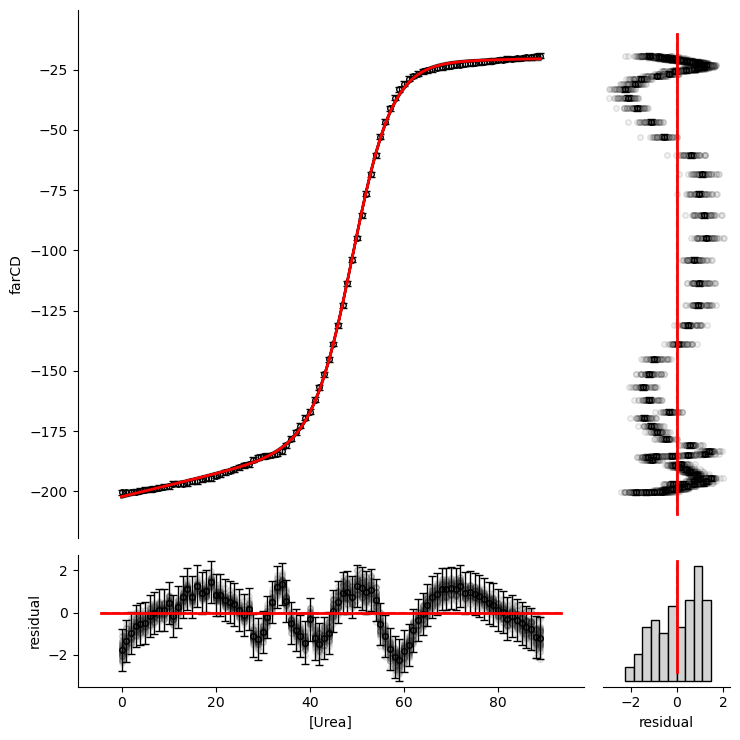

In [13]:
# Define column names from your DataFrame
osmolyte_col = 'concentration'
signal_col = 'farCD'

# Extract data from the DataFrame
osmolyte = df[osmolyte_col].values
y_obs = df[signal_col].values

# Set a realistic uniform standard deviation
y_std = 1



# Define physical constants and other non-fittable arguments
T = 298.15
R = 0.001987
non_fit_kwargs = {"osmolyte": osmolyte,
                  "R": R,
                  "T": T}

# Set up the fitter instance. It will now automatically use the
# new, correct default values from the function definition.
f = dataprob.setup(some_function=linear_extrapolation,
                   method="ml",
                   non_fit_kwargs=non_fit_kwargs)

# Perform the maximum likelihood fit
f.fit(y_obs=y_obs,
      y_std=y_std)

# Generate and display the summary plot
fig = dataprob.plot_summary(f, x_label="[Urea]", y_label="farCD")

not doing corner plot for parameter  b_native
not doing corner plot for parameter  m_native
not doing corner plot for parameter  b_denat
not doing corner plot for parameter  m_denat


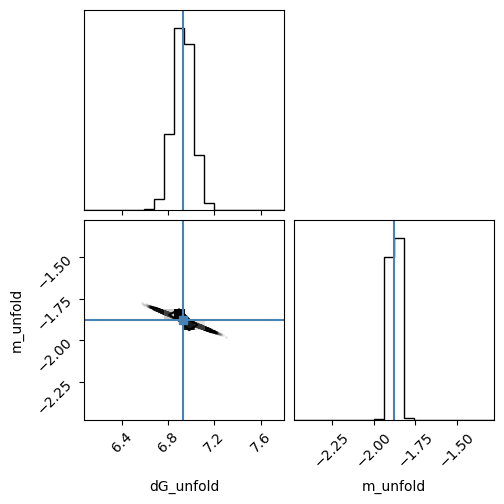

In [14]:
fig = dataprob.plot_corner(f,filter_params=["native","denat"])


In [15]:
f.fit_df

,name,estimate,std,low_95,high_95,guess,fixed,lower_bound,upper_bound,prior_mean,prior_std
name,,,,,,,,,,,
dG_unfold,dG_unfold,6.930943,0.082931,6.765997,7.095889,7.0,False,-inf,inf,NaN,NaN
m_unfold,m_unfold,-1.875095,0.022708,-1.920259,-1.829931,-2.0,False,-inf,inf,NaN,NaN
b_native,b_native,-202.148743,0.334140,-202.813334,-201.484152,-200.0,False,-inf,inf,NaN,NaN
m_native,m_native,6.284369,0.236333,5.814313,6.754425,15.0,False,-inf,inf,NaN,NaN
b_denat,b_denat,-23.584579,2.129074,-27.819222,-19.349936,-25.0,False,-inf,inf,NaN,NaN
m_denat,m_denat,0.472040,0.365638,-0.255200,1.199279,0.5,False,-inf,inf,NaN,NaN


In [9]:
f.fit_quality

,description,is_good,value,message
name,,,,
success,fit success status,True,True,
num_obs,number of observations,True,90,
num_param,number of fit parameters,True,6,There are 84 more observations than fit parame...
lnL,log likelihood,True,-122.604486,
chi2,chi^2 goodness-of-fit,True,0.579139,A p-value of 5.791e-01 for the a goodness-of-f...
reduced_chi2,reduced chi^2,True,0.961446,A reduced chi^2 value of 0.961 is consistent w...
mean0_resid,t-test for residual mean != 0,True,1.0,A p-value of 1.000e+00 for the one-sample t-te...
durbin-watson,Durbin-Watson test for correlated residuals,False,0.210262,A Durbin-Watson test-statistic of 0.210 is is ...
ljung-box,Ljung-Box test for correlated residuals,False,0.0,A p-value of 0.000e+00 for the Ljung-Box test ...
